In [ ]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [5]:
df.head()  
# AT - Temperature
# V - Vaccum calue
# AP - Pressure
# RH - Humidity
# PE - Energy(produced)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [8]:
X = df.drop(columns = ["PE"])
y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


# Conversion of loaded data into Tensors

In [57]:
# split our data

from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state=42)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
import torch
import torch.nn as nn

In [60]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)


X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [61]:
print(type(X_train_scaled))
print(type(X_test_scaled))
print(y_train.shape)
print(type(y_train))
print(type(y_train_tensor))

# to convert that series to ==> column vector
# so .view(-1,1) is used => Basically it takes all elements and stack them vertically into one column  ( -1 automatically takes the value of n from (n,) of pandas.Series shape)


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(7654,)
<class 'pandas.core.series.Series'>
<class 'torch.Tensor'>


In [62]:
# Data set & Data loader

# dataloader creates batches for us and for shuffling
# It defines how the data will be loaded for training
# Data loader class cannot access raw data directly from Tensor which is stored in RAM
# So we need help of Tensor dataset class : it accesses and defines dataset and give dataset to data loader class

# Architecture 

In [63]:
# Since we have 4 input featues , we need to pass 4 values in input layer

# Just randomly we will take 2 hidden layers and 6 neurons in each Hidden layer (Every neuron is connected to each and every other )

# And connect these 2nd hidden layer to Output Neuron/Layer

In [64]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [65]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32)

In [66]:
# Defining ANN Model 

In [67]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd Hidden
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)
    
    

In [68]:
# we can modify loass function and optimizer
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [69]:
print(train_dataset)

# Training the ANN

In [70]:
train_losses = []
val_losses = []

best_val_loss =  float("inf")

epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # Total training loss for 1 epoch

    for xb, yb in train_loader:

        optimizer.zero_grad()
        # xb is single batch i/p features and yb is labels of one batch

        outputs = model(
            xb
        )  # forward propagation.....  predicted outputs for this batch
        loss = criterion(outputs, yb)  # computes loss for 1 batch
        loss.backward()  # Backprop...  computes gradients

        optimizer.step()  # Parametes updation

        running_loss += loss.item()  # loss is a tensor --> py float (conversion)

    epoch_train_loss = running_loss / len(train_loader)

    train_losses.append(epoch_train_loss)


    # Validation 
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  #no grad compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} --> Training loss = {epoch_train_loss} & Validation loss = {epoch_val_loss} ")


    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(),"Best_model.pt") # .pt or .pth

Epoch 1/50 --> Training loss = 205961.2748046875 & Validation loss = 204779.546875 
Epoch 2/50 --> Training loss = 202088.89733072917 & Validation loss = 197204.75 
Epoch 3/50 --> Training loss = 185301.82252604168 & Validation loss = 169298.796875 
Epoch 4/50 --> Training loss = 146694.9819986979 & Validation loss = 122038.28125 
Epoch 5/50 --> Training loss = 96133.2004720052 & Validation loss = 71779.046875 
Epoch 6/50 --> Training loss = 52385.5603515625 & Validation loss = 37110.5078125 
Epoch 7/50 --> Training loss = 28283.032670084634 & Validation loss = 22220.1015625 
Epoch 8/50 --> Training loss = 19282.01357014974 & Validation loss = 17162.345703125 
Epoch 9/50 --> Training loss = 15797.170658365885 & Validation loss = 14398.732421875 
Epoch 10/50 --> Training loss = 13229.911813354493 & Validation loss = 11929.58984375 
Epoch 11/50 --> Training loss = 10834.566969807942 & Validation loss = 9546.892578125 
Epoch 12/50 --> Training loss = 8525.321366373699 & Validation loss = 

Text(0, 0.5, 'Losses')

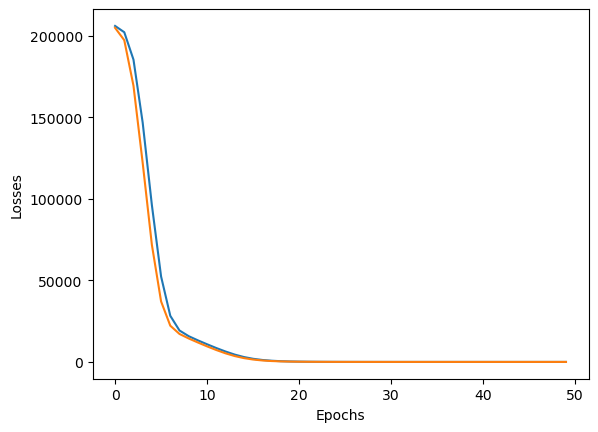

In [72]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Train_loss": train_losses,
    "Val_loss": val_losses

})

plt.plot(loss_df["Train_loss"] , label = "Training Loss")
plt.plot(loss_df["Val_loss"] , label = "Validaton Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

# Loading the best Model 

In [73]:
model.load_state_dict(torch.load("Best_model.pt"))

<All keys matched successfully>

# Evaluation

In [74]:
model.eval()

with torch.no_grad():
   train_preds =  model(X_train_tensor)
   test_preds = model(X_test_tensor)

   train_mse_loss = criterion(train_preds,y_train_tensor)
   test_mse_loss = criterion(test_preds,y_test_tensor)

print(f"Training MSE : {train_mse_loss.item()}")
print(f"Testing MSE : {test_mse_loss.item()}")

Training MSE : 20.881311416625977
Testing MSE : 19.161731719970703


In [75]:
from sklearn.metrics import r2_score

print(f"R2_score : {r2_score(y_test , test_preds)}")

R2_score : 0.9330346936550092


In [76]:
predicted_df = pd.DataFrame(
    test_preds.numpy(), columns = ["Predicted_Values"]
)

actual_df = pd.DataFrame(
    y_test.values , columns = ["Actual_Values"]
)

pd.concat([predicted_df,actual_df],axis = 1)

,Predicted_Values,Actual_Values
0,435.360809,433.27
1,437.068024,438.16
2,461.277802,458.42
3,476.385101,480.82
4,435.133881,441.41
...,...,...
1909,451.625488,456.70
1910,431.724701,438.04
1911,467.831146,467.80
1912,431.132477,437.14
